<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>MLP using SciKitLearn - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|

**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [43]:
# Install Requirements Using Pip
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [44]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [45]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [46]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [47]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [48]:
internet_required = False

In [49]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [50]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

In [51]:
df.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous', 'y',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

In [52]:
df.sample(5)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,education_numeric,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
25896,1.136095,0.226532,1.0,0.0,-0.569351,-0.251940,0.0,0.0,0.909091,0.333333,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
32758,0.194355,-0.077272,1.0,0.0,0.076230,0.616335,0.0,1.0,0.272727,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7082,-0.653211,-0.436253,1.0,1.0,0.076230,-0.251940,0.0,0.0,0.363636,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
22794,0.288529,-0.367938,0.0,0.0,0.399020,-0.251940,0.0,0.0,0.636364,0.333333,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
20605,-0.935732,-0.251671,0.0,0.0,0.399020,-0.251940,0.0,0.0,0.636364,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

We now will create two arrays: X and y. 
X contains the entire dataset features, while y contains the corresponding target values.

In [54]:
X = df.drop('y', axis=1)
y = df['y'].values.reshape(-1, 1)

Now it is necessary to split the input dataset into two parts - testing and training data.<br>
Like the 'from scratch' split, this data is boith shuffled and stratified to ensure that the proportions of the 'y' class remain the same.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, shuffle=True, stratify=y)

In [56]:
# Check proportions of class 1 ('yes')
print(f"Train 'Yes' ratio: {np.mean(y_train)*100:.2f}%")
print(f"Test 'Yes' ratio: {np.mean(y_test)*100:.2f}%")

Train 'Yes' ratio: 11.70%
Test 'Yes' ratio: 11.70%


In [57]:
# Create a scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

In [58]:
# Initialize MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, ),
                    activation='logistic',
                    solver='adam',
                    max_iter=4000,
                    random_state=67)

# Train the model
result = mlp.fit(X_train, y_train)

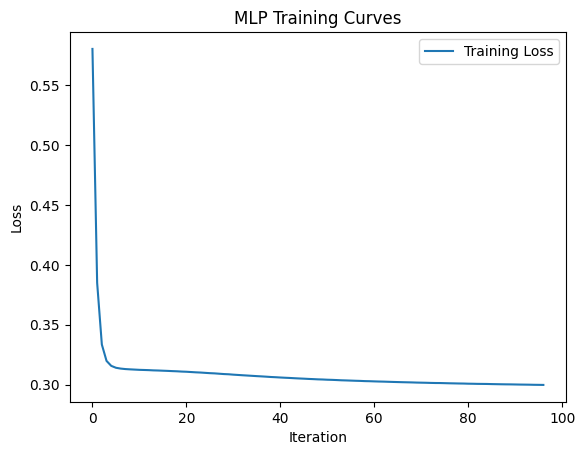

In [59]:
plt.plot(result.loss_curve_, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Curves')
plt.legend()
plt.show()

In [60]:
y_pred = mlp.predict(X_test)                                      

In [61]:
# Calculate accuracy
accuracy = accuracy_score(y_test,y_pred)                                     
print(f"Accuracy: {accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94      7985
         1.0       0.66      0.17      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



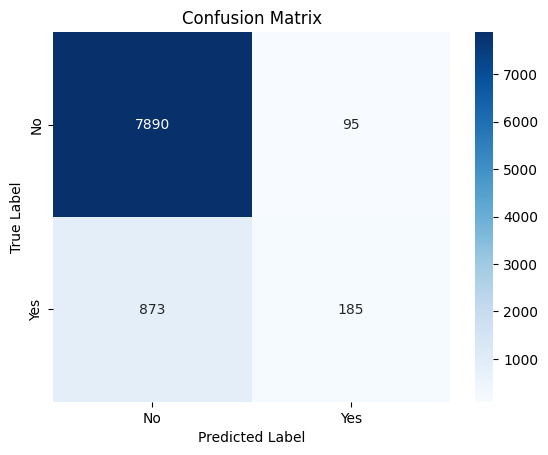

In [62]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Need to do grid search here...

In [63]:
sys.exit('Stopping notebook run here.')   

SystemExit: Stopping notebook run here.